### **Load & Explore**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Iris.csv')
df.drop(columns=['Id'], inplace=True)

print("Shape:", df.shape)
print("\nHead:\n", df.head())
print("\nInfo:")
df.info()
print("\nDescribe:\n", df.describe())
print("\nNull Values:\n", df.isnull().sum())
print("\nSpecies Count:\n", df['Species'].value_counts())

Shape: (150, 5)

Head:
    SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Describe:
        SepalLengthCm  SepalWidthCm  PetalLengthCm  Peta

### **Species Distribution & Feature Averages**

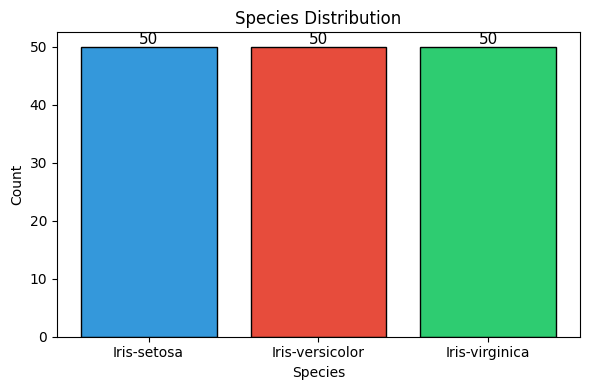


Average Features by Species:
                  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
Species                                                                  
Iris-setosa               5.01          3.42           1.46          0.24
Iris-versicolor           5.94          2.77           4.26          1.33
Iris-virginica            6.59          2.97           5.55          2.03


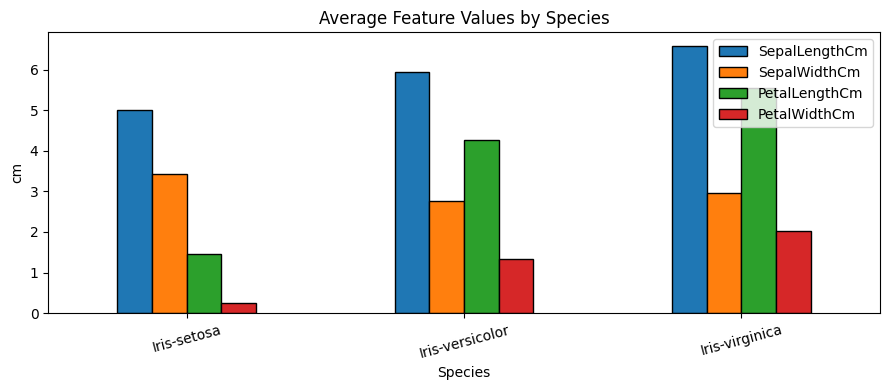

In [2]:
# Species Count Bar
species_counts = df['Species'].value_counts()
plt.figure(figsize=(6,4))
bars = plt.bar(species_counts.index, species_counts.values,
               color=['#3498db','#e74c3c','#2ecc71'], edgecolor='black')
plt.title('Species Distribution')
plt.xlabel('Species')
plt.ylabel('Count')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             str(int(bar.get_height())),
             ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# Feature Averages by Species
avg = df.groupby('Species').mean().round(2)
print("\nAverage Features by Species:\n", avg)

avg.plot(kind='bar', figsize=(9,4), edgecolor='black')
plt.title('Average Feature Values by Species')
plt.xlabel('Species')
plt.ylabel('cm')
plt.xticks(rotation=15)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### **Histogram & Boxplot**

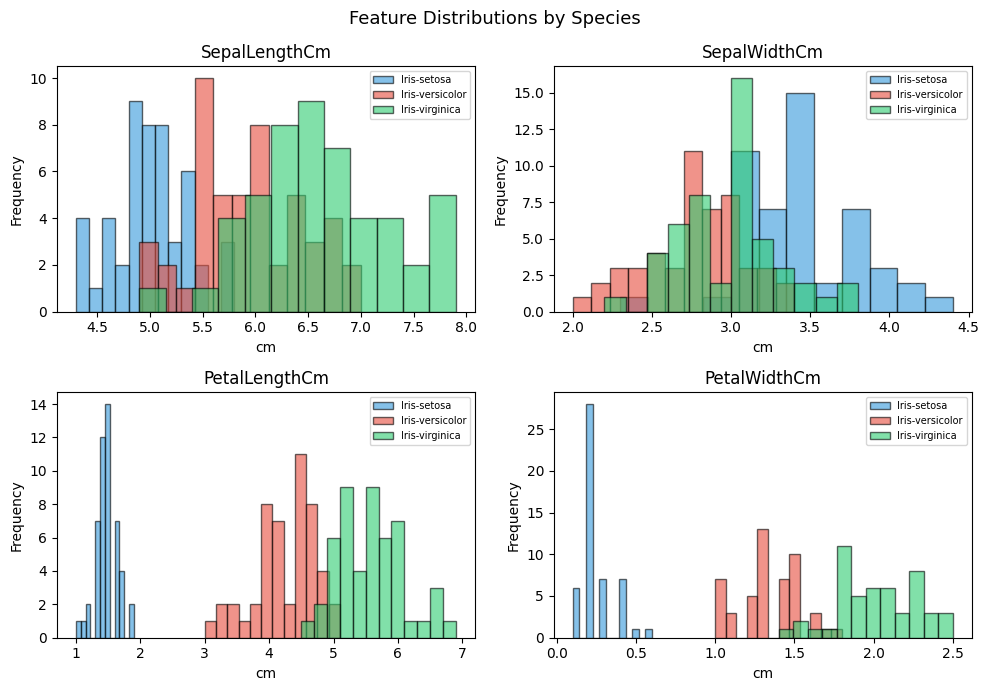

C:\Users\Star\AppData\Local\Temp\ipykernel_11096\2250378754.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=species, patch_artist=True)
C:\Users\Star\AppData\Local\Temp\ipykernel_11096\2250378754.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=species, patch_artist=True)
C:\Users\Star\AppData\Local\Temp\ipykernel_11096\2250378754.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=species, patch_artist=True)
C:\Users\Star\AppData\Local\Temp\ipykernel_11096\2250378754.py:24: MatplotlibDeprecationWarning: The 'labels' param

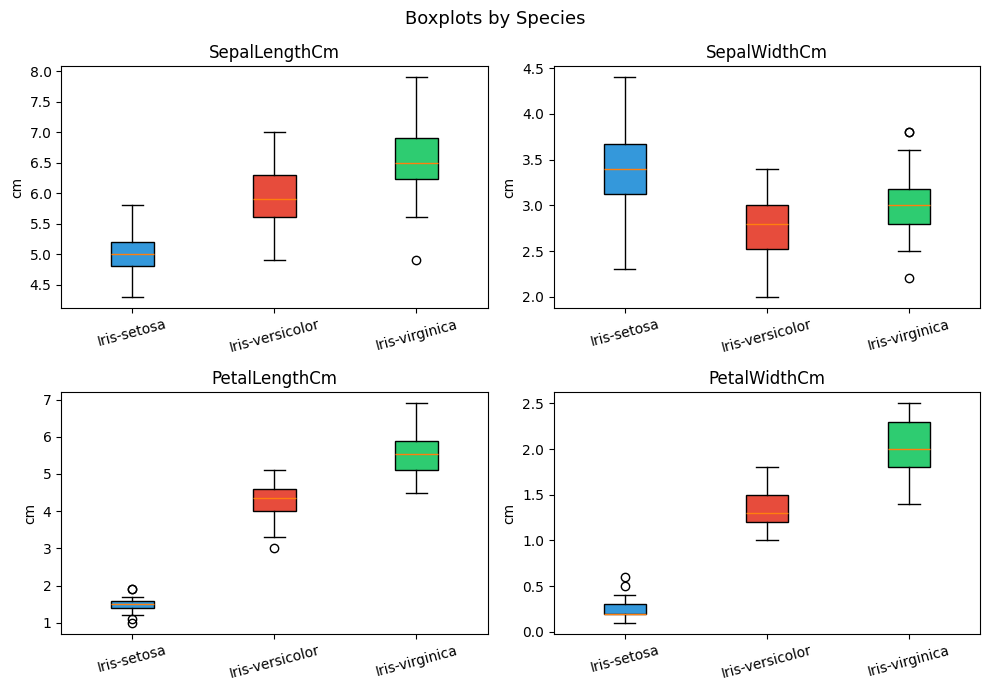

In [3]:
features = ['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']
colors   = ['#3498db','#e74c3c','#2ecc71']
species  = df['Species'].unique()

# Histogram for each feature
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle('Feature Distributions by Species', fontsize=13)
for ax, feat in zip(axes.flatten(), features):
    for sp, col in zip(species, colors):
        ax.hist(df[df['Species']==sp][feat], bins=12,
                alpha=0.6, color=col, edgecolor='black', label=sp)
    ax.set_title(feat)
    ax.set_xlabel('cm')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# Boxplot for each feature
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle('Boxplots by Species', fontsize=13)
for ax, feat in zip(axes.flatten(), features):
    data = [df[df['Species']==sp][feat].values for sp in species]
    bp = ax.boxplot(data, labels=species, patch_artist=True)
    for patch, col in zip(bp['boxes'], ['#3498db','#e74c3c','#2ecc71']):
        patch.set_facecolor(col)
    ax.set_title(feat)
    ax.set_ylabel('cm')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

### **Scatter Plots & Correlation Heatmap**

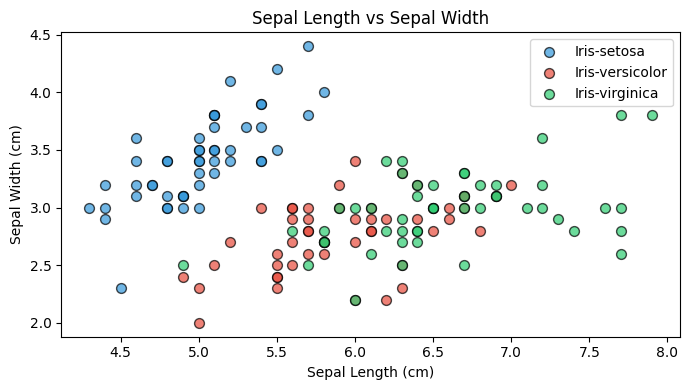

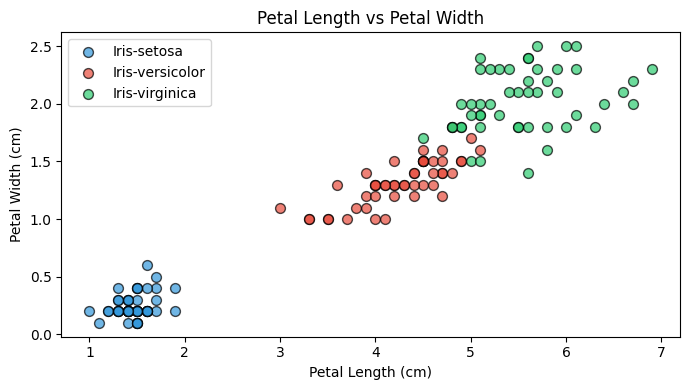

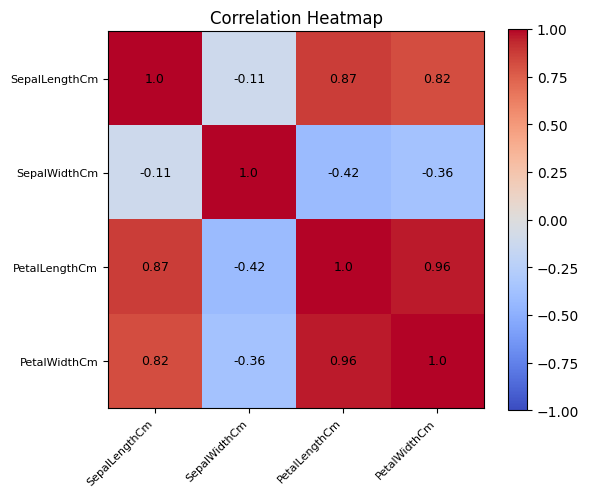

In [4]:
colors_map = {
    'Iris-setosa'    : '#3498db',
    'Iris-versicolor': '#e74c3c',
    'Iris-virginica' : '#2ecc71'
}

# Sepal Length vs Sepal Width
plt.figure(figsize=(7,4))
for sp, col in colors_map.items():
    subset = df[df['Species'] == sp]
    plt.scatter(subset['SepalLengthCm'], subset['SepalWidthCm'],
                color=col, label=sp, edgecolors='black', alpha=0.7, s=50)
plt.title('Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend()
plt.tight_layout()
plt.show()

# Petal Length vs Petal Width
plt.figure(figsize=(7,4))
for sp, col in colors_map.items():
    subset = df[df['Species'] == sp]
    plt.scatter(subset['PetalLengthCm'], subset['PetalWidthCm'],
                color=col, label=sp, edgecolors='black', alpha=0.7, s=50)
plt.title('Petal Length vs Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.tight_layout()
plt.show()

# Correlation Heatmap
corr = df[features].corr().round(2)
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(features, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, corr.iloc[i,j], ha='center', va='center', fontsize=9)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()